In [1]:
import numpy as np
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
#%matplotlib inline,
import matplotlib as mpl
import matplotlib.pylab as pl
mpl.rcParams['figure.dpi'] = 300
plt.style.use('tableau-colorblind10')
#plt.rcParams['text.usetex'] = True,
plt.rcParams.update({
    'font.size': 13,
    'legend.fontsize': 13,
    'xtick.major.size': 5.0,
    'xtick.minor.size': 3.0,
    'xtick.major.width': 0.3,
    'xtick.minor.width': 0.3,
    'ytick.major.size': 5.0,
    'ytick.minor.size': 3.0,
    'ytick.major.width': 0.3,
    'ytick.minor.width': 0.3,
    'axes.linewidth': 0.3,
    'font.family': 'Liberation Serif', #'DejaVu Serif', #'times new roman', #'latin modern roman',
    'mathtext.fontset': 'cm',
    'legend.frameon': False,
})

In [ ]:
# for paper in ["AIMD_saiz_300K", "AIMD_saiz_9000K", "AIMD_saiz_10000K", "AIMD_saiz_11000K"]:
#     for j, bond in enumerate(["Si-C"]):
#         rdf_df = np.loadtxt(f"{paper}_{bond}.csv", delimiter=",")
#         rdf_df = rdf_df[np.argsort(rdf_df[:,0])]
#         rdf_df[:,1] -= 1.0
#         # override original file
#         np.savetxt(f"{paper}_{bond}.csv", rdf_df, delimiter=",")

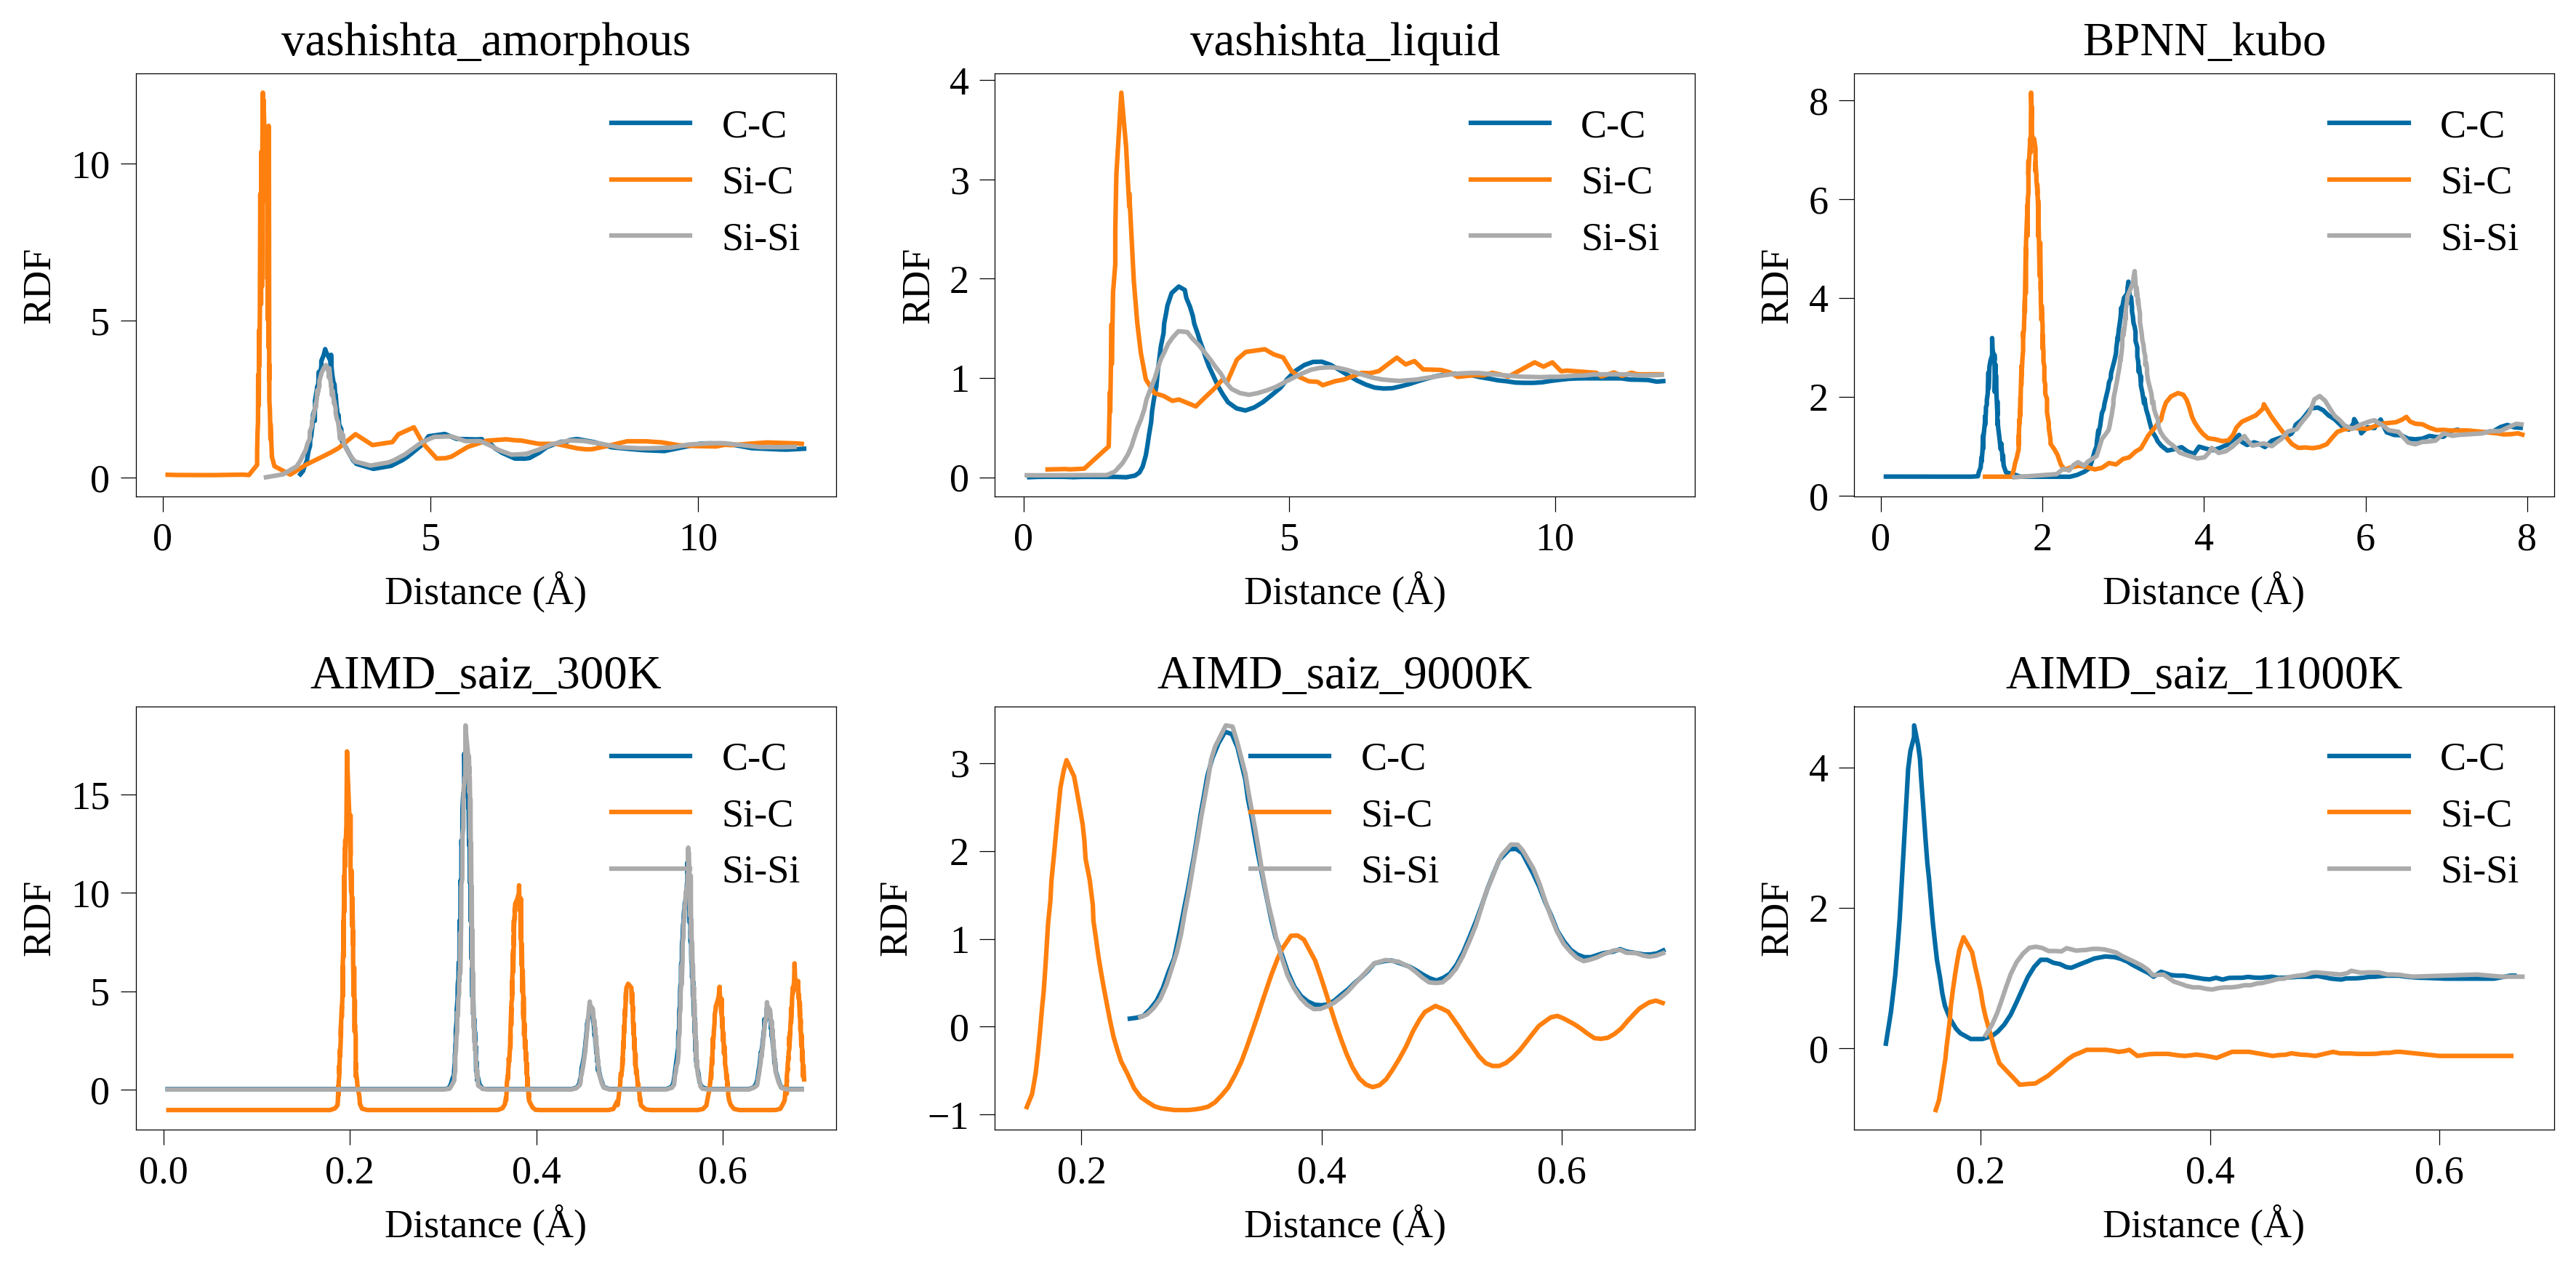

In [3]:
def plot_rdf(ax, paper, linestyle="-"):  
    ax.set_prop_cycle(None)
    for j, bond in enumerate(["C-C", "Si-C", "Si-Si"]):
        rdf_df = np.loadtxt(f"{paper}_{bond}.csv", delimiter=",")
        rdf_df = rdf_df[np.argsort(rdf_df[:,0])]
        ax.plot(rdf_df[:,0], rdf_df[:,1], label=bond, linestyle=linestyle)
    ax.set_xlabel("Distance (Å)")
    ax.set_ylabel("RDF")
    ax.legend()
    ax.set_title(paper)


fig, axes = plt.subplots(2, 3, figsize=(12,6))
plot_rdf(axes[0, 0], "vashishta_amorphous")
plot_rdf(axes[0, 1], "vashishta_liquid")
plot_rdf(axes[0, 2], "BPNN_kubo")

plot_rdf(axes[1, 0], "AIMD_saiz_300K")
plot_rdf(axes[1, 1], "AIMD_saiz_9000K")
plot_rdf(axes[1, 2], "AIMD_saiz_11000K")

fig.tight_layout()
fig.savefig("rdf_comparison.pdf", dpi=300)